In [2]:
from __future__ import print_function
import sys
import os
import random
import torch
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd

# Get the current working directory (the folder where the .ipynb is)
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))

if parent_dir not in sys.path:
    sys.path.append(parent_dir)


In [3]:
# Location of Training Data
spectra_path = f"{parent_dir}\\data\\absorptionData_HybridGAN.csv"

# Root directory for dataset (images must be in a subdirectory within this folder)
img_data_path = f"{parent_dir}\\data"

In [4]:
# set a trial name for saving results
trial_name = "trial_1"


time_stamp = time.strftime("%Y%m%d-%H%M%S")
trial_name = f"{trial_name}_{time_stamp}"

print(f"Trial Name: {trial_name}")


# Location to Save Models and results (Generators and Discriminators)
results_dir = f"{parent_dir}\\results\\{trial_name}"
save_dir = f"{parent_dir}\\results\\{trial_name}\\models"


Trial Name: trial_1_20260430-200752


In [5]:
# create results directory if it doesn't exist
os.makedirs(results_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)

In [6]:
def Excel_Tensor(spectra_path):
    # Location of excel data
    excelData = pd.read_csv(spectra_path, header=0, index_col=0)
    excelDataSpectra = excelData.iloc[
        :, :800
    ]  # index until the last point of the spectra in the Excel file
    excelDataTensor = torch.tensor(excelDataSpectra.values).type(torch.FloatTensor)
    return excelData, excelDataSpectra, excelDataTensor


excelData, excelDataSpectra, excelDataTensor = Excel_Tensor(spectra_path)


In [7]:
## -- TRAINING PARAMETERS -- ##

# Number of workers for dataloader (for Windows workers must = 0, for reference: https://github.com/pytorch/pytorch/issues/2341)
workers = 1

# Batch size during training
batch_size = 16

# Spatial size of training images. All images will be resized to this size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 3

In [8]:
dataset = dset.ImageFolder(
    root=img_data_path,
    transform=transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
    ),
)
# Create the dataloader
dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=False, num_workers=workers
)

In [9]:
len(dataloader.dataset)

18770

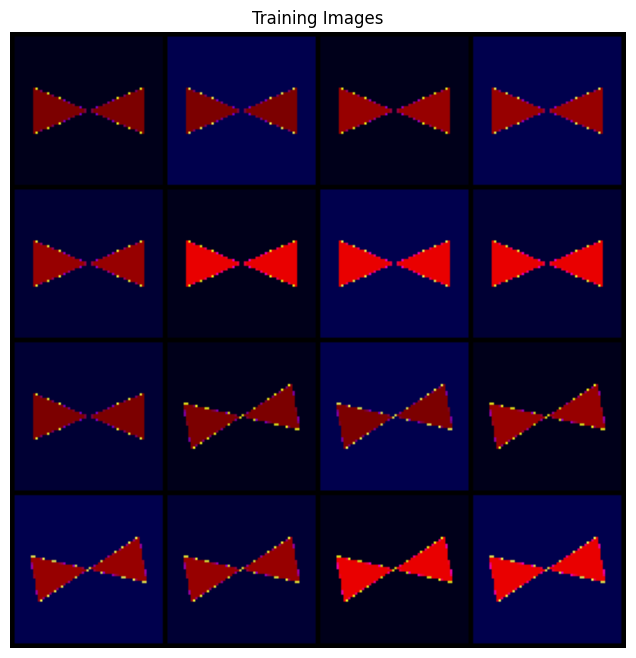

In [43]:
# print a 4x4 grid of images from the first batch
real_batch = next(iter(dataloader))
grid = vutils.make_grid(real_batch[0].to("cpu")[:16], nrow=4, padding=2, normalize=True)

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(grid.cpu(), (1, 2, 0)))
plt.show()


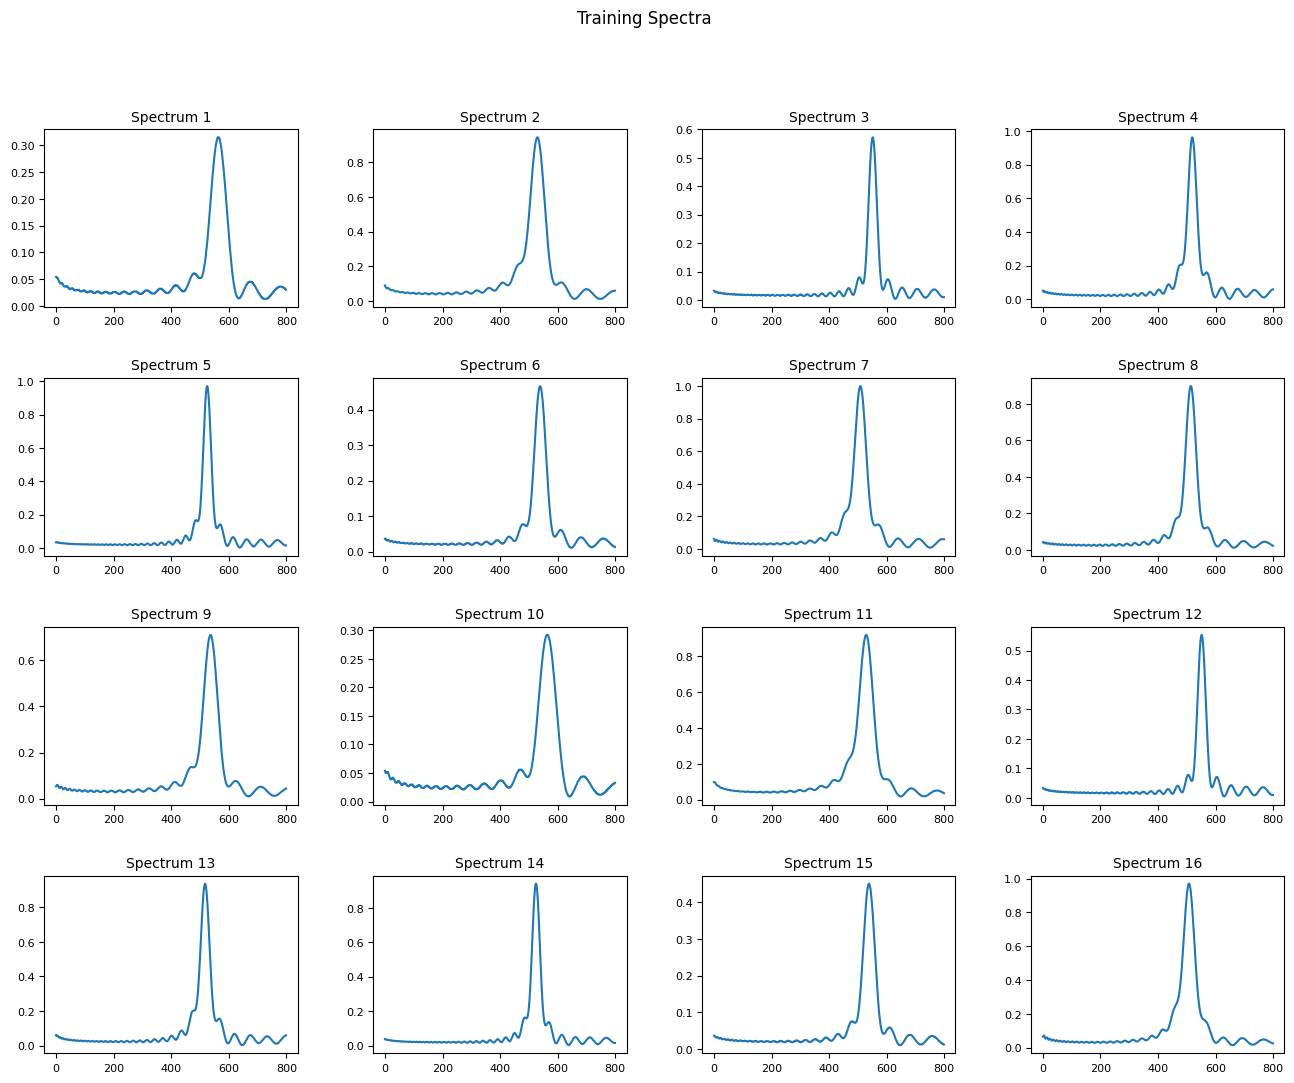

In [44]:
# Visualize the spectra in a 4x4 grid and adjust spacing
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, idx in zip(axes.flatten(), range(batch_size)):
    ax.plot(excelDataSpectra.iloc[idx, :].values)
    ax.set_title(f"Spectrum {idx + 1}", fontsize=10)
    ax.tick_params(axis="both", which="major", labelsize=8)

fig.suptitle("Training Spectra")
fig.subplots_adjust(hspace=0.4, wspace=0.3)  # adjust hspace/wspace to change spacing
plt.show()
